# <font color='Blue'>🧠 Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow (Fashion MNIST)</font>

## 📌 Visão geral do projeto
Este notebook apresenta a construção de um modelo de **Deep Learning com TensorFlow/Keras** para classificar imagens do dataset **Fashion MNIST**.

O desenvolvimento foi organizado seguindo um **pipeline de projeto de Inteligância Artificial**, cobrindo desde a definição do problema até a etapa de inferância com novas imagens.

## 🗺️ Pipeline do Projeto de IA
1. 🎯 **Definição do problema**
2. 📥 **Coleta dos dados**
3. 🧹 **Pré-processamento**
4. 🇷🇪 **Construção do modelo**
5. 🚀 **Treinamento**
6. 📊 **Avaliação**
7. 🖼️ **Deploy / inferância**

## 1️⃣ 🎯 Definição do problema
Construir um modelo de **classificação de imagens** capaz de reconhecer diferentes tipos de vestuário e acessírios presentes no dataset **Fashion MNIST**.

## 📚 Dataset utilizado
**Fashion MNIST**

## 🔗 Referância oficial
https://keras.io/api/datasets/fashion_mnist/

## 📝 Observações
Este notebook foi desenvolvido como uma evolução de um projeto de classificação multi-classe. Foram aplicadas as adaptações técnicas necessárias para o processamento do **Fashion MNIST**, que trabalha com imagens em **tons de cinza** e dimensão **28 x 28 pixels**, garantindo a correta arquitetura da rede neural para este novo domínio.

## 🔧 Etapa preparatória — Configuração do ambiente

Antes de iniciar o pipeline principal, esta seção organiza o ambiente de execução do projeto:
- Verificação da versão do Python;
- Disponibilidade do TensorFlow no Google Colab;
- Configuração de imports;

Essa etapa não faz parte do problema de IA em si, mas é importante para garantir **execução correta, organização e consistência experimental**.



In [ ]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [ ]:
# TensorFlow normalmente já vem instalado no Google Colab.
# !pip install -q tensorflow

import tensorflow as tf
print('Versão do TensorFlow:', tf.__version__)

Versão do TensorFlow: 2.19.0


In [ ]:
# Silencia mensagens menos importantes do TensorFlow
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

## 2️⃣ 📥 Coleta dos dados — Matéria-prima do projeto

Nesta etapa, é realizado o carregamento do dataset **Fashion MNIST**, que será utilizado como base para treinamento e avaliação do modelo.

O **Fashion MNIST** contém imagens em **tons de cinza** de peças de roupa, com dimensão **28 x 28 pixels**. As estatísticas do Dataset são:
- **Imagens de Treino:** 60.000
- **Imagens de Teste:** 10.000
- **Total de Imagens:** 70.000

Cada imagem pertence a uma das 10 classes abaixo:

- **T-shirt/top** → Camiseta/Top
- **Trouser** → Calça
- **Pullover** → Pulôver
- **Dress** → Vestido
- **Coat** → Casaco
- **Sandal** → Sandália
- **Shirt** → Camisa
- **Sneaker** → Tênis
- **Bag** → Bolsa
- **Ankle boot** → Bota

✅ Nesta etapa, o objetivo é compreender **qual é a matéria-prima do problema** e como os dados chegam ao modelo.



In [ ]:
# Carrega o dataset Fashion MNIST - já está disponível no Keras
(imagens_treino, labels_treino), (imagens_teste, labels_teste) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Classes das imagens
nomes_classes = [
    'Camiseta/Top', 'Calça', 'Pulôver', 'Vestido', 'Casaco',
    'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota'
]

In [ ]:
# Formato dos dados
print('Formato das imagens de treino:', imagens_treino.shape)
print('Formato das labels de treino:', labels_treino.shape)
print('Formato das imagens de teste:', imagens_teste.shape)
print('Formato das labels de teste:', labels_teste.shape)

Formato das imagens de treino: (60000, 28, 28)
Formato das labels de treino: (60000,)
Formato das imagens de teste: (10000, 28, 28)
Formato das labels de teste: (10000,)


## 3️⃣ 🧹 Pré-processamento e visualização das imagens

Após o carregamento dos dados, é necessário realizar o **pré-processamento**, isto é, preparar as imagens para que possam ser utilizadas corretamente pela rede neural.

Nesta etapa, serão executadas ações como:
- Normalização dos pixels;
- Verificação do formato das imagens;
- Exibição de amostras do dataset.

Esta fase é fundamental porque melhora a qualidade da entrada fornecida ao modelo e facilita a interpretação visual do conjunto de dados.



In [ ]:
# Normaliza os valores dos pixels para a faixa [0, 1]
imagens_treino = imagens_treino.astype('float32') / 255.0
imagens_teste = imagens_teste.astype('float32') / 255.0

# Adiciona o canal das imagens para usar CNN com Conv2D
# Antes: (amostras, 28, 28)
# Depois: (amostras, 28, 28, 1)
imagens_treino = np.expand_dims(imagens_treino, axis=-1)
imagens_teste = np.expand_dims(imagens_teste, axis=-1)

print('Novo formato das imagens de treino:', imagens_treino.shape)
print('Novo formato das imagens de teste:', imagens_teste.shape)

Novo formato das imagens de treino: (60000, 28, 28, 1)
Novo formato das imagens de teste: (10000, 28, 28, 1)


In [ ]:
# Função para exibir as imagens
def visualiza_imagens(images, labels, class_names, n_linhas=3, n_colunas=5):
    plt.figure(figsize=(10, 7))
    total = n_linhas * n_colunas

    for i in range(total):
        plt.subplot(n_linhas, n_colunas, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.xlabel(class_names[int(labels[i])])

    plt.tight_layout()
    plt.show()

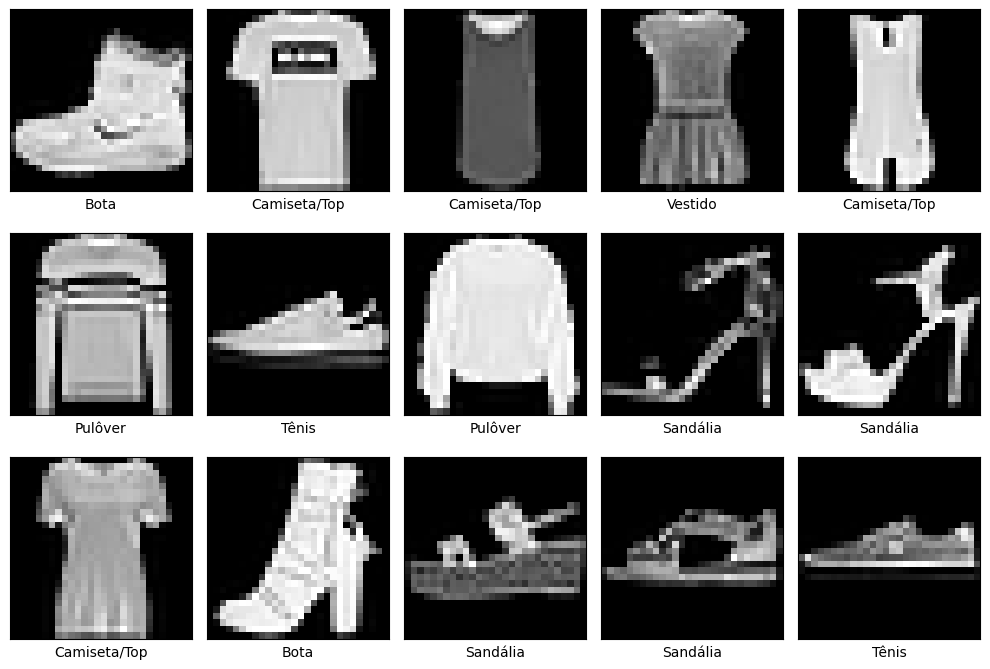

In [ ]:
# Executa a função
visualiza_imagens(imagens_treino, labels_treino, nomes_classes)

## 4️⃣ 🏗️ Construção do modelo

Nesta etapa, é definida a **arquitetura da Rede Neural Convolucional (CNN)** responsável por aprender padrões visuais presentes nas imagens do dataset.

A estrutura adotada inclui:
- Camadas **Conv2D**, para extração de características;
- Camadas **MaxPooling2D**, para redução dimensional;
- Camada **Flatten**, para transição entre a parte convolucional e a parte densa;
- Camadas **Dense**, para classificação final;
- Função de ativação **softmax** na saída, adequada para classificação multiclasse.

✅ O objetivo desta fase é estruturar o modelo que será treinado para reconhecer as diferentes categorias de roupas.



In [ ]:
# Arquitetura do modelo -> Feature Learning + Classificação
modelo_lia = models.Sequential()

modelo_lia.add(layers.Input(shape=(28, 28, 1)))
modelo_lia.add(layers.Conv2D(32, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Camadas de classificação
modelo_lia.add(layers.Flatten())
modelo_lia.add(layers.Dense(64, activation='relu'))
modelo_lia.add(layers.Dropout(0.3))
modelo_lia.add(layers.Dense(10, activation='softmax'))

In [ ]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilação do modelo
modelo_lia.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
%%time
# Treinamento do modelo
# Aqui é utilizado validation_split para separar uma parte do conjunto de treino
# e preservar o conjunto de teste apenas para a avaliação final.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)
history = modelo_lia.fit(
    imagens_treino,
    labels_treino,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7613 - loss: 0.6530 - val_accuracy: 0.8488 - val_loss: 0.4112
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8540 - loss: 0.4091 - val_accuracy: 0.8723 - val_loss: 0.3492
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8764 - loss: 0.3445 - val_accuracy: 0.8867 - val_loss: 0.3051
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8876 - loss: 0.3110 - val_accuracy: 0.8932 - val_loss: 0.2859
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8988 - loss: 0.2830 - val_accuracy: 0.9007 - val_loss: 0.2673
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9053 - loss: 0.2636 - val_accuracy: 0.9029 - val_loss: 0.2654
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9096 - loss: 0.2470 - val_accuracy: 0.9054 - val_loss: 0.2666
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9166 - loss: 0.2317 - val_accuracy: 0

## 5️⃣ 🚀 Treinamento do modelo e análise do aprendizado

Com a arquitetura já definida, o próximo passo é realizar o **treinamento do modelo**, isto é, permitir que a rede neural ajuste seus parâmetros a partir dos exemplos do conjunto de treino.

Após o treinamento, também serão analisadas as **curvas de desempenho**, permitindo acompanhar:
- A evolução da **acurácia**;
- A evolução da **função de perda (loss)**;
- Possíveis sinais de **subajuste** ou **sobreajuste**.

📈 Essa etapa é essencial para verificar se o modelo realmente está aprendendo de forma adequada.



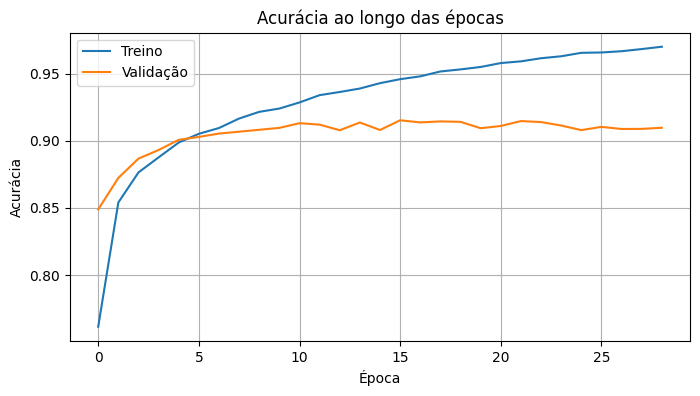

In [ ]:
# Histórico de accuracy e loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia ao longo das épocas')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

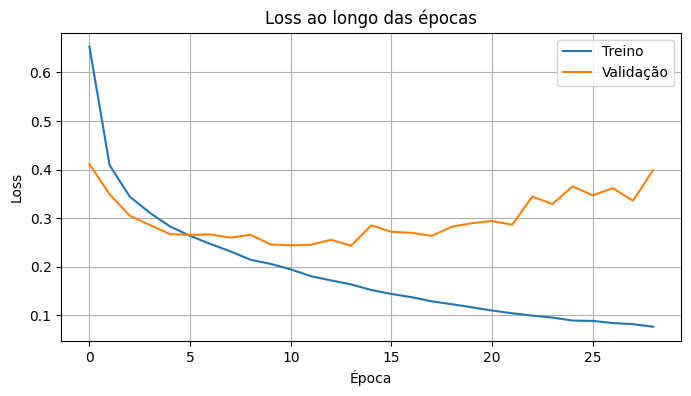

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss ao longo das épocas')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 6️⃣ 📊 Avaliação do modelo

Depois do treinamento, o modelo deve ser avaliado com dados que ele **não utilizou para aprender diretamente**, permitindo medir sua capacidade de generalização.

Nesta etapa, serão analisados:
- **Loss** no conjunto de teste;
- **Accuracy** no conjunto de teste;
- **Matriz de confusão**;
- **Relatório de classificação**.

🎯 O objetivo é verificar o quão bem o modelo consegue classificar corretamente novas imagens do Fashion MNIST.



In [ ]:
# Avalia o modelo com o conjunto de teste
erro_teste, acc_teste = modelo_lia.evaluate(imagens_teste, labels_teste, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.9146 - loss: 0.2594


In [ ]:
print('\nLoss com dados de teste:', erro_teste)
print('Acurácia com dados de teste:', acc_teste)


Loss com dados de teste: 0.2593633830547333
Acurácia com dados de teste: 0.9146000146865845


In [ ]:
# Previsões do modelo no conjunto de teste
y_pred = modelo_lia.predict(imagens_teste)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = labels_teste

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


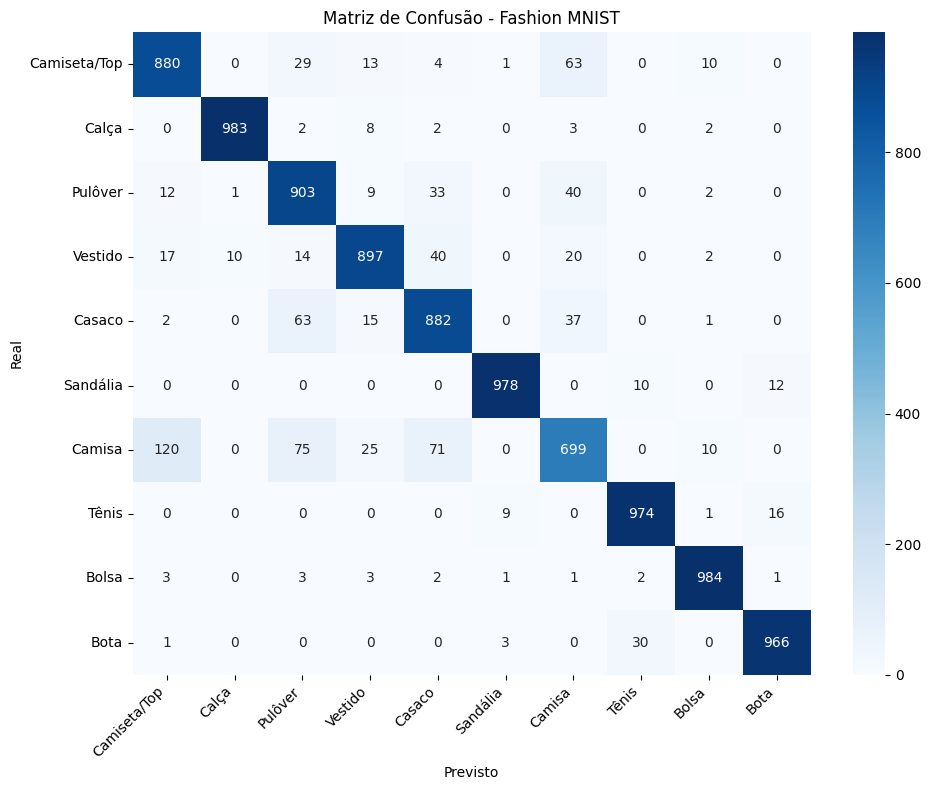

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Fashion MNIST')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Relatório de classificação
print(classification_report(y_true, y_pred_classes, target_names=nomes_classes))

              precision    recall  f1-score   support

Camiseta/Top       0.85      0.88      0.86      1000
       Calça       0.99      0.98      0.99      1000
     Pulôver       0.83      0.90      0.86      1000
     Vestido       0.92      0.90      0.91      1000
      Casaco       0.85      0.88      0.87      1000
    Sandália       0.99      0.98      0.98      1000
      Camisa       0.81      0.70      0.75      1000
       Tênis       0.96      0.97      0.97      1000
       Bolsa       0.97      0.98      0.98      1000
        Bota       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### 6.1 🔍 Visualizando previsões do modelo

Além das métricas numéricas, também é importante observar exemplos práticos das previsões realizadas pela rede neural.

Nesta seção, serão exibidas imagens do conjunto de teste acompanhadas de:
- Classe real;
- Classe prevista pelo modelo.

Essa visualização ajuda a interpretar melhor os acertos e eventuais erros de classificação.



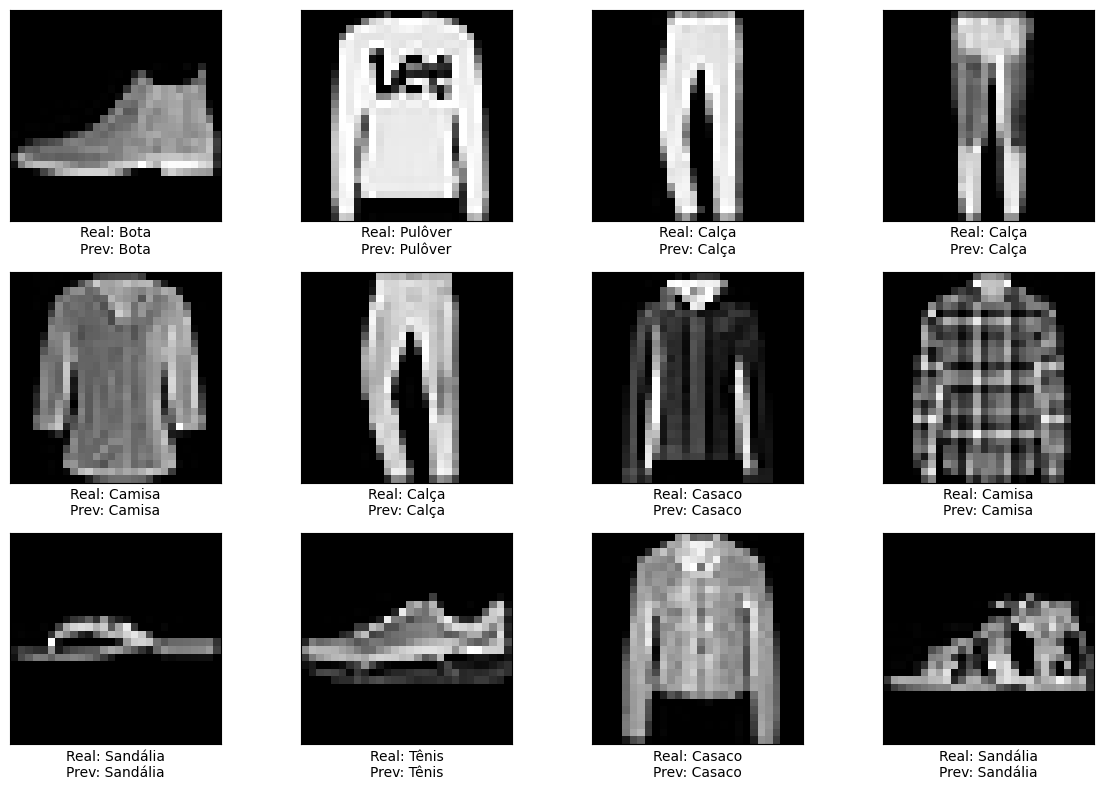

In [ ]:
# Exibe algumas previsões do modelo
def mostra_previsoes(images, y_real, y_prev, nomes_classes, quantidade=12):
    plt.figure(figsize=(12, 8))
    for i in range(quantidade):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        classe_real = nomes_classes[int(y_real[i])]
        classe_prev = nomes_classes[int(y_prev[i])]

        plt.xlabel(f'Real: {classe_real}\nPrev: {classe_prev}')

    plt.tight_layout()
    plt.show()

mostra_previsoes(imagens_teste, y_true, y_pred_classes, nomes_classes)

## 7️⃣ 🖼️ Deploy / inferência

Após treinar e avaliar o modelo, chega-se à etapa de **inferência**, na qual o sistema passa a receber uma nova imagem e gerar uma predição.

Nesta primeira parte, a inferência será feita utilizando uma imagem já existente no conjunto de teste, simulando o comportamento de uso do modelo em produção.



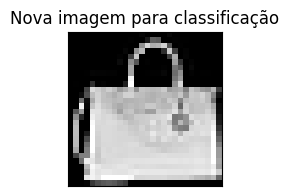

Classe real: Bolsa


In [ ]:
# Seleciona uma imagem do conjunto de teste como se fosse uma nova imagem
indice = 30

nova_imagem = imagens_teste[indice]
label_real = labels_teste[indice]

plt.figure(figsize=(2, 2))
plt.imshow(nova_imagem.squeeze(), cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('Nova imagem para classificação')
plt.show()

print('Classe real:', nomes_classes[int(label_real)])

In [ ]:
# Expande a dimensão para o formato (1, 28, 28, 1)
nova_imagem_array = np.expand_dims(nova_imagem, axis=0)
print('Formato da nova imagem:', nova_imagem_array.shape)

Formato da nova imagem: (1, 28, 28, 1)


In [ ]:
# Previsão da nova imagem
previsoes = modelo_lia.predict(nova_imagem_array)
print('Probabilidades previstas:')
print(previsoes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
Probabilidades previstas:
[[4.4080604e-11 2.6742311e-22 1.4228793e-18 1.4827633e-19 5.9138179e-20
  6.4977842e-20 7.5406583e-15 1.0300149e-19 1.0000000e+00 1.0718625e-21]]


In [ ]:
# Obtém a classe com maior probabilidade
classe_prevista = np.argmax(previsoes, axis=1)[0]
nome_classe_prevista = nomes_classes[int(classe_prevista)]

print('A nova imagem foi classificada como:', nome_classe_prevista)

A nova imagem foi classificada como: Bolsa


### 7.1 🌐 Teste com imagem local externa

Nesta seção, o modelo será testado com uma **imagem local externa**, como uma roupa baixada da internet e enviada para o Google Colab.

Para que a imagem seja compatível com o padrão aprendido pelo modelo, será necessário realizar algumas etapas de adaptação:

1. Abrir a imagem;
2. Converter para **tons de cinza**;
3. Redimensionar para **28 x 28 pixels**;
4. Normalizar os pixels para a faixa **[0, 1]**;
5. Inverter os pixels, se necessário.

⚠️ **Observações importantes**
- O Fashion MNIST foi treinado com imagens simples e padronizadas;
- Imagens reais podem possuir fundo claro, sombras, texturas e ruídos;
- Por isso, mesmo com o pré-processamento correto, a classificação pode não ser perfeita.

Ainda assim, esta etapa é muito importante, pois aproxima o projeto de um cenário mais próximo de uso real.



In [ ]:
# Imports para teste com imagem local
from PIL import Image

try:
    from google.colab import files
    ambiente_colab = True
except ImportError:
    ambiente_colab = False

print('Executando no Google Colab?' , ambiente_colab)


Executando no Google Colab? True


In [ ]:
# Upload da imagem no Google Colab
# Se estiver no Colab, execute esta célula e escolha uma imagem do seu computador.
# Se não estiver no Colab, informe manualmente o caminho do arquivo na célula seguinte.

if ambiente_colab:
    uploaded = files.upload()
    caminho_imagem = list(uploaded.keys())[0]
    print('Arquivo enviado:', caminho_imagem)
else:
    print('Se você não estiver no Colab, pule esta célula e use a próxima para informar o caminho da imagem.')


Saving images1.jpg to images1.jpg
Arquivo enviado: images1.jpg


In [ ]:
# Caminho manual da imagem
# Use esta célula se a imagem já estiver salva no ambiente do notebook.
# Exemplo: caminho_imagem = '/content/minha_roupa.jpg'

# caminho_imagem = '/content/minha_roupa.jpg'
print('Defina a variável caminho_imagem caso não tenha feito upload na célula anterior.')


Defina a variável caminho_imagem caso não tenha feito upload na célula anterior.


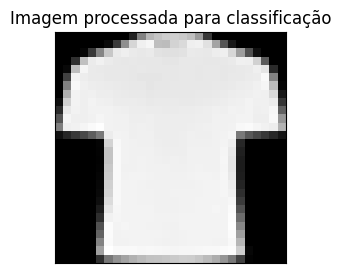

In [ ]:
# Pré-processamento da imagem local
# Ordem adotada: abrir -> converter para cinza -> redimensionar -> normalizar -> inverter (opcional)

inverter_pixels = True  # Troque para False se a imagem já estiver clara em fundo escuro

img = Image.open(caminho_imagem)
img = img.convert('L')
img = img.resize((28, 28))

img_array = np.array(img).astype('float32') / 255.0

if inverter_pixels:
    img_array = 1.0 - img_array

plt.figure(figsize=(3, 3))
plt.imshow(img_array, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('Imagem processada para classificação')
plt.show()


In [ ]:
# Ajusta o formato da imagem para o padrão esperado pela CNN: (1, 28, 28, 1)
img_array = np.expand_dims(img_array, axis=-1)
img_array = np.expand_dims(img_array, axis=0)

print('Formato final da imagem:', img_array.shape)


Formato final da imagem: (1, 28, 28, 1)


In [ ]:
# Classificação da imagem local
pred_local = modelo_lia.predict(img_array)
classe_prevista_local = np.argmax(pred_local, axis=1)[0]

print('Probabilidades previstas:')
print(pred_local)
print('Classe prevista para a imagem local:', nomes_classes[int(classe_prevista_local)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Probabilidades previstas:
[[9.9650913e-01 8.7556195e-08 1.0821162e-03 2.2236882e-05 2.9745524e-06
  5.8606662e-09 2.3822261e-03 3.9190426e-12 1.1733854e-06 1.8643158e-10]]
Classe prevista para a imagem local: Camiseta/Top


## 8️⃣ 📝 Considerações Finais sobre o Modelo

O desenvolvimento deste modelo para o **Fashion MNIST** utilizou técnicas de Deep Learning otimizadas para imagens em **tons de cinza** e dimensão **28 x 28 pixels**. Os principais pontos implementados no projeto foram:

- Arquitetura de Rede Neural Convolucional (CNN) configurada para entrada **(28, 28, 1)**;
- Mapeamento de categorias específicas para as 10 classes do dataset Fashion MNIST;
- Visualização de dados e resultados em escala de cinza para melhor interpretação das features;
- Camadas de processamento convolucional projetadas para extrair padrões de vestuário;
- Implementação de um pipeline de inferância capaz de processar **imagens externas** enviadas pelo usuário.

✅ Com isso, o projeto consolida um fluxo completo de IA, desde o tratamento dos dados brutos até a predição de casos reais com alta precisão.